In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline              # Дает возможность объединить все этапы, которые проходят X и y до обучения модели
from sklearn.model_selection import GridSearchCV   # Автоматический подбор гиперпараметров на основе заданного критерия
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import BaggingClassifier

In [21]:
def visualize_prediction(y_true, y_pred, model):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot()
    plt.show()

def show_metrics(y_true, y_pred):
    print('Среднее значение Y: ', np.mean(y_true))
    print('Accuracy: ', accuracy_score(y_true, y_pred)),
    print('Precision: ', precision_score(y_true, y_pred))
    print('Recall: ', recall_score(y_true, y_pred))
    print('F1: ', f1_score(y_true, y_pred))
    print('ROC-AUC: ', roc_auc_score(y_true, y_pred))

# 1. Загружаем датасет

In [2]:
data = sm.datasets.get_rdataset("mlc_churn", 'modeldata').data
data['target'] = np.where(data["churn"] == 'yes', 1, 0)
data["total_charge"] = data[[col for col in data.columns if col.find("charge")!= -1]].sum(axis = 1)

data.head()

,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,...,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,churn,target,total_charge
0,KS,128,area_code_415,no,yes,25,265.1,110,45.07,197.4,...,244.7,91,11.01,10.0,3,2.70,1,no,0,75.56
1,OH,107,area_code_415,no,yes,26,161.6,123,27.47,195.5,...,254.4,103,11.45,13.7,3,3.70,1,no,0,59.24
2,NJ,137,area_code_415,no,no,0,243.4,114,41.38,121.2,...,162.6,104,7.32,12.2,5,3.29,0,no,0,62.29
3,OH,84,area_code_408,yes,no,0,299.4,71,50.90,61.9,...,196.9,89,8.86,6.6,7,1.78,2,no,0,66.80
4,OK,75,area_code_415,yes,no,0,166.7,113,28.34,148.3,...,186.9,121,8.41,10.1,3,2.73,3,no,0,52.09


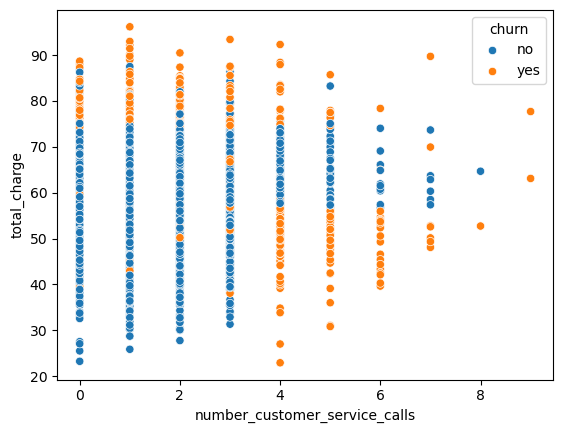

In [3]:
fig = plt.figure()
sns.scatterplot(data = data, x = 'number_customer_service_calls', y = 'total_charge', hue = 'churn')
plt.show()

# 2. Делим датасет на обучающую, валидационную и тестовую выборки

In [5]:
target_col = ["target"]
features_col = ["number_customer_service_calls","total_charge"]

X = data[features_col]
y = data[target_col]

# Вся выборка делится на 60% обучающей и 40% тестовой
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.4, random_state = 42, stratify = y)
# Тестовые 40% дополнительно делятся пополам на валидационную и собственно тестовую
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size = 0.5, random_state = 42, stratify = y_test)
# Получаем разделение 60% обучающая, 20% валидационная, 20% тестовая

print("Размер обучающей выборки: ", X_train.shape[0])
print("Размер валидационной выборки: ", X_val.shape[0])
print("Размер тестовой выборки: ", X_test.shape[0], end = '\n\n')
print("Доля оттока в обучающей выборке: ", y_train.mean()[0])
print("Доля оттока в валидационной выборке: ", y_val.mean()[0])
print("Доля оттока в тестовой выборке: ", y_test.mean()[0])

Размер обучающей выборки:  3000
Размер валидационной выборки:  1000
Размер тестовой выборки:  1000

Доля оттока в обучающей выборке:  0.14133333333333334
Доля оттока в валидационной выборке:  0.142
Доля оттока в тестовой выборке:  0.141


C:\Users\D\AppData\Local\Temp\ipykernel_8692\388835520.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Доля оттока в обучающей выборке: ", y_train.mean()[0])
C:\Users\D\AppData\Local\Temp\ipykernel_8692\388835520.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Доля оттока в валидационной выборке: ", y_val.mean()[0])
C:\Users\D\AppData\Local\Temp\ipykernel_8692\388835520.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser

# 3. Стекинг

## 3.1. Выбираем наилучшие классификаторы на обучающей выборке

In [6]:
def choose_base_model(estimator, param_grid, X_train, y_train):
  pipe = Pipeline(steps=[("scaler", StandardScaler()), ("classify", estimator)])
  search = GridSearchCV(pipe, param_grid, scoring = 'f1')
  search.fit(X_train, y_train)
  best_model = search.best_estimator_
  return best_model

In [7]:
model_parameters = {
    "model1" : {
        "estimator" : KNeighborsClassifier(),
        "param_grid" : {
            "classify__n_neighbors": range(3, 11, 2)
        }
    },

    "model2" : {
        "estimator" : LogisticRegression(random_state = 42),
        "param_grid" : {
            "classify__C" : np.linspace(start = 0.001, stop = 10, num = 10)
            }
        },

    "model3" : {
        "estimator" : SVC(),
        "param_grid" : {
            "classify__kernel" :("linear", "rbf"),
            "classify__C": np.linspace(start = 0.001, stop = 10, num = 10)
        }
    }
}

In [9]:
y_val_feats = pd.DataFrame(index = y_val.index)
models = {}
val_metrics = pd.DataFrame()

for model in model_parameters.keys():
  clf = model_parameters[model]["estimator"]
  param_grid = model_parameters[model]["param_grid"]
  best_model = choose_base_model(clf, param_grid, X_train, y_train)
  y_val_pred = best_model.predict(X_val)
  y_val_feats["y_pred_" + model] = y_val_pred
  models[model] = best_model

  val_metrics.loc[model, 'Accuracy'] = accuracy_score(y_val, y_val_pred)
  val_metrics.loc[model, 'Precision'] = precision_score(y_val, y_val_pred)
  val_metrics.loc[model, 'Recall'] = recall_score(y_val, y_val_pred)
  val_metrics.loc[model, 'F1-score'] = f1_score(y_val, y_val_pred)

In [16]:
# Метрики качества на валидационной выборке для базовых моделей
val_metrics

,Accuracy,Precision,Recall,F1-score
model1,0.929,0.793388,0.676056,0.730038
model2,0.866,0.785714,0.077465,0.141026
model3,0.930,0.852941,0.612676,0.713115


In [17]:
# Предсказания базовых моделей на валидационной выборке
y_val_feats.head()

,y_pred_model1,y_pred_model2,y_pred_model3
2816,0,0,0
1429,0,0,0
4258,1,0,1
1007,0,0,0
4219,0,0,0


In [18]:
# С помощью обученных базовых моделей предсказываем метки для тестовой выборки
y_test_feats = pd.DataFrame(index = y_test.index)
test_metrics = pd.DataFrame()

for model, clf in models.items():
  y_test_pred = clf.predict(X_test)
  y_test_feats["y_pred_" + model] = y_test_pred
  test_metrics.loc[model, 'Accuracy'] = accuracy_score(y_test, y_test_pred)
  test_metrics.loc[model, 'Precision'] = precision_score(y_test, y_test_pred)
  test_metrics.loc[model, 'Recall'] = recall_score(y_test, y_test_pred)
  test_metrics.loc[model, 'F1-score'] = f1_score(y_test, y_test_pred)

In [19]:
# Метрики качества на тестовой выборке для базовых моделей
test_metrics

,Accuracy,Precision,Recall,F1-score
model1,0.920,0.790476,0.588652,0.674797
model2,0.859,0.500000,0.042553,0.078431
model3,0.920,0.850575,0.524823,0.649123


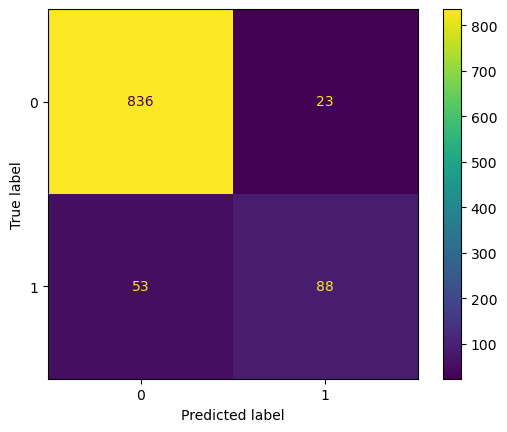

Среднее значение Y:  0.141
Accuracy:  0.924
Precision:  0.7927927927927928
Recall:  0.624113475177305
F1:  0.6984126984126984
ROC-AUC:  0.7986690775188039


In [22]:
meta_classifier = DecisionTreeClassifier(random_state = 42)
param_grid = {
    "criterion": ('gini', 'entropy', 'log_loss'),
    "max_depth": range(2,5)
}

meta_search = GridSearchCV(meta_classifier, param_grid, scoring = 'f1')
meta_search.fit(y_val_feats, y_val)
best_meta_model = meta_search.best_estimator_
y_test_pred = best_meta_model.predict(y_test_feats)

visualize_prediction(y_test, y_test_pred, best_meta_model)
show_metrics(y_test, y_test_pred)

In [23]:
# Посмотрим максимальную глубину дерева
best_meta_model.max_depth

2

##  3.2 Стэкинг автоматически

In [24]:
estimators = [('KNN', KNeighborsClassifier(n_neighbors = 5)),
              ('Logit', LogisticRegression(C = 1.112, random_state = 42)),
              ('SVM', SVC(C = 10))]

In [25]:
final_estimator = DecisionTreeClassifier(max_depth = 2, random_state = 42)

In [26]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [27]:
trained_base_estimators = []

for name, estimator in estimators:
    trained_estimator = estimator.fit(X_train_scaled, y_train)
    trained_base_estimators.append((name, trained_estimator))

stacking_clf = StackingClassifier(
    estimators = trained_base_estimators,
    final_estimator = final_estimator,
    cv = "prefit",
    passthrough = False
)

stacking_clf.fit(X_val_scaled, y_val)

C:\Users\D\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\D\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\D\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\D\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example

StackingClassifier(cv='prefit',
                   estimators=[('KNN', KNeighborsClassifier()),
                               ('Logit',
                                LogisticRegression(C=1.112, random_state=42)),
                               ('SVM', SVC(C=10))],
                   final_estimator=DecisionTreeClassifier(max_depth=2,
                                                          random_state=42))

In [28]:
y_test_pred = stacking_clf.predict(X_test_scaled)

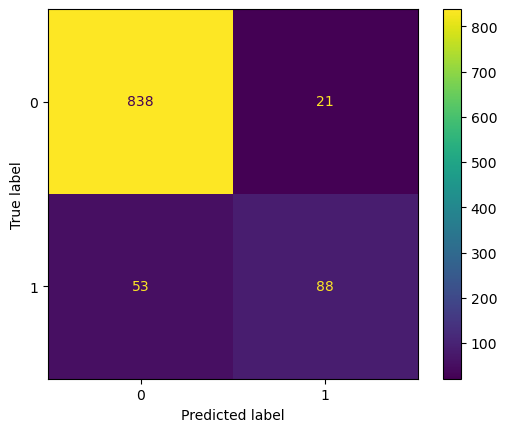

Среднее значение Y:  0.141
Accuracy:  0.926
Precision:  0.8073394495412844
Recall:  0.624113475177305
F1:  0.704
ROC-AUC:  0.7998332218727038


In [29]:
visualize_prediction(y_test, y_test_pred, stacking_clf)
show_metrics(y_test, y_test_pred)

# 4. Бэггинг

## 4.1. Бэггинг вручную

In [34]:
target_col = ["target"]
features_col = ["number_customer_service_calls","total_charge"]

X = data[features_col]
y = data[target_col]

# Вся выборка делится на 60% обучающей и 40% тестовой
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42, stratify = y)

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
base_model = DecisionTreeClassifier(random_state = 42)
n_samples = 100
train_size = X_train_scaled.shape[0]
frac = n_samples / train_size

print("Размер обучающей выборки:", train_size)
print("Доля порции данных:", frac)

Размер обучающей выборки: 3350
Доля порции данных: 0.029850746268656716


In [36]:
y_test_base_preds = pd.DataFrame(index = y_test.index)
for i in range(n_samples):
  subsample = pd.concat([X_train, y_train], axis = 1).sample(frac = frac, random_state = i)
  X_train_subsample = scaler.transform(subsample[features_col])
  base_model.fit(X_train_subsample, subsample[target_col])
  y_test_base_preds[i] = base_model.predict(X_test_scaled)

In [37]:
y_test_base_preds.head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
1319,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
1991,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
498,1,1,0,0,1,1,0,1,0,0,...,1,1,0,1,0,1,0,1,0,1
3857,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4185,0,1,1,1,0,1,1,1,1,0,...,1,0,1,0,0,1,1,1,1,0


In [38]:
y_test_pred = np.where(y_test_base_preds.mean(axis = 1) >= 0.5, 1, 0)

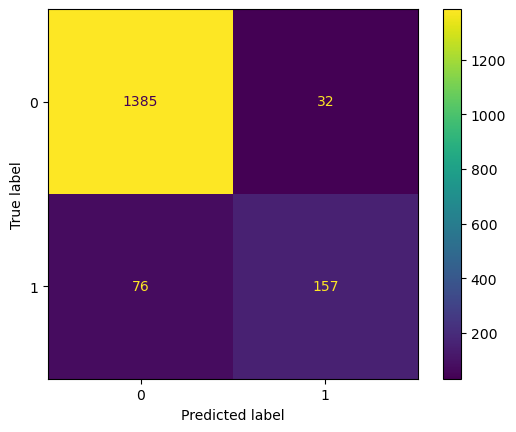

Среднее значение Y:  0.1412121212121212
Accuracy:  0.9345454545454546
Precision:  0.8306878306878307
Recall:  0.6738197424892703
F1:  0.7440758293838863
ROC-AUC:  0.82561841041189


In [40]:
visualize_prediction(y_test, y_test_pred, base_model)
show_metrics(y_test, y_test_pred)

## 4.2. А если обучить одиночный классификатор?

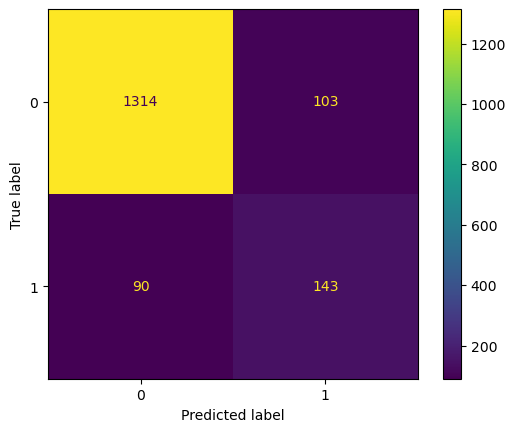

Среднее значение Y:  0.1412121212121212
Accuracy:  0.883030303030303
Precision:  0.5813008130081301
Recall:  0.6137339055793991
F1:  0.5970772442588727
ROC-AUC:  0.7705225632343008


In [41]:
base_model.fit(X_train_scaled, y_train)
y_test_pred = base_model.predict(X_test_scaled)
visualize_prediction(y_test, y_test_pred, base_model)
show_metrics(y_test, y_test_pred)

## 4.3. То же автоматически

In [46]:
base_model = DecisionTreeClassifier(random_state = 42)
bagging = BaggingClassifier(base_model, max_samples = frac, n_estimators = n_samples)

In [47]:
bagging.fit(X_train_scaled, y_train)

C:\Users\D\anaconda3\Lib\site-packages\sklearn\ensemble\_bagging.py:878: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  max_samples=0.029850746268656716, n_estimators=100)

In [48]:
y_test_pred = bagging.predict(X_test_scaled)

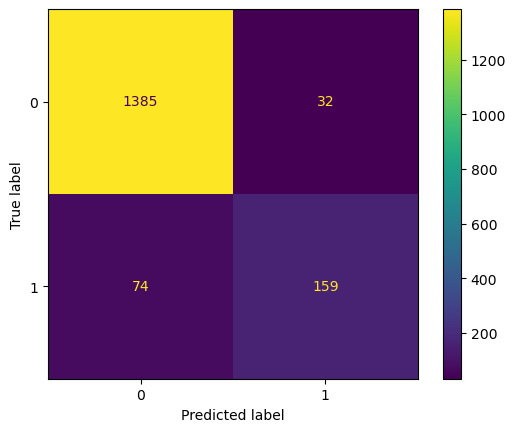

Среднее значение Y:  0.1412121212121212
Accuracy:  0.9357575757575758
Precision:  0.8324607329842932
Recall:  0.6824034334763949
F1:  0.75
ROC-AUC:  0.8299102559054522


In [50]:
visualize_prediction(y_test, y_test_pred, bagging)
show_metrics(y_test, y_test_pred)

# 5. Random Forest

In [51]:
target_col = ["target"]
features_col = ["number_customer_service_calls","total_charge"]

X = data[features_col]
y = data[target_col]

# Вся выборка делится на 60% обучающей и 40% тестовой
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42, stratify = y)

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [52]:
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

C:\Users\D\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier()

In [53]:
clf.feature_importances_

array([0.13132, 0.86868])

In [54]:
y_test_pred = clf.predict(X_test_scaled)

C:\Users\D\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


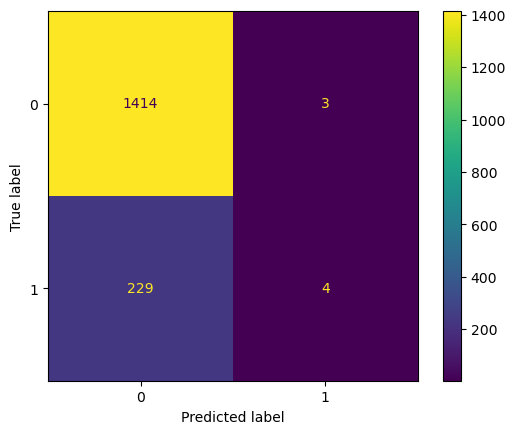

Среднее значение Y:  0.1412121212121212
Accuracy:  0.8593939393939394
Precision:  0.5714285714285714
Recall:  0.017167381974248927
F1:  0.03333333333333333
ROC-AUC:  0.5075251165340545


In [55]:
visualize_prediction(y_test, y_test_pred, clf)
show_metrics(y_test, y_test_pred)

# 6. Подбираем гиперпараметры для Random Forest

In [56]:
pipe = Pipeline(steps=[("scaler", StandardScaler()), ("classify", RandomForestClassifier())])
param_grid = {
            "classify__n_estimators": [10, 50, 100, 150],
            "classify__max_features": np.linspace(start = 0.1, stop = 1.0, num = 10)
            }
search = GridSearchCV(pipe, param_grid, scoring = 'f1')
search.fit(X_train, y_train)
best_model = search.best_estimator_
y_test_pred = best_model.predict(X_test)

C:\Users\D\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\D\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\D\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\D\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using r

In [57]:
search.best_estimator_[1]

RandomForestClassifier(max_features=np.float64(1.0), n_estimators=50)

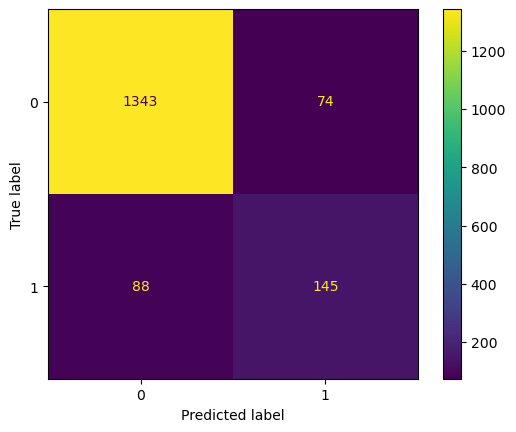

Среднее значение Y:  0.1412121212121212
Accuracy:  0.9018181818181819
Precision:  0.6621004566210046
Recall:  0.6223175965665236
F1:  0.6415929203539823
ROC-AUC:  0.7850472951075385


In [58]:
visualize_prediction(y_test, y_test_pred, best_model)
show_metrics(y_test, y_test_pred)